In [1]:
# If not installed already (uncomment as needed):
# !pip install torch torch-geometric pandas tqdm

import os, json, torch, pandas as pd
from pathlib import Path
import importlib

import train_loop
import data_utils
importlib.reload(data_utils)
importlib.reload(train_loop)

from data_utils import load_graphs, attach_labels_and_noisy, build_loaders
from train_loop import train, evaluate
import torch, numpy as np, random
from torch_geometric.loader import DataLoader

In [2]:
# EDIT THESE:
GRAPHS_PT = "/home/macula/SMATousi/Desktop/all_6q_new/trotter/all_6_trotter_graphs_1200.pt"      # <-- Step 1 output (a list[Data])
BATCH_SIZE  = 16
NUM_WORKERS = 0
PIN_MEMORY  = torch.cuda.is_available()

In [3]:
graphs = torch.load(GRAPHS_PT, weights_only=False)   # list[Data] or InMemoryDataset
N = len(graphs)
print(f"Loaded {N} graphs")

def _set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_loaders_random(graphs, train_ratio=0.8, seed=42, batch_size=BATCH_SIZE):
    _set_seed(seed)
    idx = np.arange(len(graphs))
    np.random.shuffle(idx)
    n_train = int(len(idx) * train_ratio)
    train_idx, val_idx = idx[:n_train], idx[n_train:]
    train_set = [graphs[i] for i in train_idx]
    val_set   = [graphs[i] for i in val_idx]
    print(f"Random split: train={len(train_set)}, val={len(val_set)}")
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        train_idx, val_idx
    )

def build_loaders_by_indices(graphs, train_idx, val_idx, batch_size=BATCH_SIZE):
    train_set = [graphs[i] for i in train_idx]
    val_set   = [graphs[i] for i in val_idx]
    print(f"By indices: train={len(train_set)}, val={len(val_set)}")
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    )

def build_loaders_stratified_by_step(graphs, train_ratio=0.8, seed=42, batch_size=BATCH_SIZE):
    """Stratify by data.step (trotter_step). If missing, falls back to random."""
    # collect indices per step
    buckets = {}
    missing = []
    for i, g in enumerate(graphs):
        if hasattr(g, "step") and g.step is not None:
            s = int(float(g.step.item())) if torch.is_tensor(g.step) else int(g.step)
            buckets.setdefault(s, []).append(i)
        else:
            missing.append(i)
    if not buckets:
        print("No `step` metadata; falling back to random.")
        return build_loaders_random(graphs, train_ratio, seed, batch_size)

    _set_seed(seed)
    train_idx, val_idx = [], []
    for s, idxs in buckets.items():
        idxs = np.array(idxs)
        np.random.shuffle(idxs)
        cut = int(len(idxs) * train_ratio)
        train_idx.extend(idxs[:cut].tolist())
        val_idx.extend(idxs[cut:].tolist())
    # distribute any missing-step items proportionally
    if missing:
        miss = np.array(missing); np.random.shuffle(miss)
        cut = int(len(miss) * train_ratio)
        train_idx += miss[:cut].tolist()
        val_idx   += miss[cut:].tolist()

    train_set = [graphs[i] for i in train_idx]
    val_set   = [graphs[i] for i in val_idx]
    print(f"Stratified by step: train={len(train_set)}, val={len(val_set)}; steps={sorted(buckets.keys())}")
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
        np.array(train_idx), np.array(val_idx)
    )

# ---- Choose ONE of the following depending on your need ----

# A) Simple random split
train_loader, val_loader, train_idx, val_idx = build_loaders_random(graphs, train_ratio=0.625, seed=123, batch_size=BATCH_SIZE)



Loaded 1200 graphs
Random split: train=750, val=450


In [6]:
model_cfg = dict(d_model=96, layers=3, heads=4, dropout=0.01637060709208519, use_noisy=True)

net, hist = train(model_cfg, (train_loader, val_loader),
                  epochs=260, 
                  lr=0.0028069921132593072, 
                  wd=1.6477856850815681e-09, 
                  patience=93, 
                  scheduler_patience=47, 
                  scheduler_factor=0,
                  best_ckpt_path="best_qem_graph_transformer.pt",
                  device="cpu")


# torch.save(net.state_dict(), MODEL_OUT)
# print("Saved:", MODEL_OUT)


Epoch 001 | train 0.0747 | val 0.0537 | MAE 0.2891 | lr 2.81e-03 | new
Epoch 002 | train 0.0500 | val 0.0348 | MAE 0.2339 | lr 2.81e-03 | new
Epoch 003 | train 0.0283 | val 0.0104 | MAE 0.1119 | lr 2.81e-03 | new
Epoch 004 | train 0.0097 | val 0.0083 | MAE 0.1037 | lr 2.81e-03 | new
Epoch 005 | train 0.0061 | val 0.0065 | MAE 0.0927 | lr 2.81e-03 | new
Epoch 006 | train 0.0054 | val 0.0045 | MAE 0.0741 | lr 2.81e-03 | new
Epoch 007 | train 0.0043 | val 0.0044 | MAE 0.0733 | lr 2.81e-03 | new
Epoch 008 | train 0.0037 | val 0.0037 | MAE 0.0639 | lr 2.81e-03 | new
Epoch 009 | train 0.0047 | val 0.0039 | MAE 0.0653 | lr 2.81e-03 | new
Epoch 010 | train 0.0036 | val 0.0056 | MAE 0.0855 | lr 2.81e-03 | new
Epoch 011 | train 0.0034 | val 0.0036 | MAE 0.0656 | lr 2.81e-03 | new
Epoch 012 | train 0.0036 | val 0.0032 | MAE 0.0593 | lr 2.81e-03 | new
Epoch 013 | train 0.0037 | val 0.0037 | MAE 0.0603 | lr 2.81e-03 | new
Epoch 014 | train 0.0033 | val 0.0037 | MAE 0.0654 | lr 2.81e-03 | new
Epoch 

KeyboardInterrupt: 

In [13]:
model_cfg = dict(d_model=96, layers=3, heads=4, dropout=0.1, use_noisy=True)

net, hist = train(model_cfg, (train_loader, val_loader),
                  epochs=500, 
                  lr=0.0028069921132593072, 
                  wd=1.6477856850815681e-09, 
                  patience=93, 
                  scheduler_patience=10, 
                  scheduler_factor=0.3,
                  best_ckpt_path="best_qem_graph_transformer.pt")


# torch.save(net.state_dict(), MODEL_OUT)
# print("Saved:", MODEL_OUT)

Epoch 001 | train 0.0731 | val 0.0604 | MAE 0.2728 | lr 2.81e-03 | new
Epoch 002 | train 0.0470 | val 0.0446 | MAE 0.2288 | lr 2.81e-03 | new
Epoch 003 | train 0.0312 | val 0.0179 | MAE 0.1544 | lr 2.81e-03 | new
Epoch 004 | train 0.0142 | val 0.0065 | MAE 0.0904 | lr 2.81e-03 | new
Epoch 005 | train 0.0075 | val 0.0052 | MAE 0.0765 | lr 2.81e-03 | new
Epoch 006 | train 0.0060 | val 0.0048 | MAE 0.0734 | lr 2.81e-03 | new
Epoch 007 | train 0.0062 | val 0.0072 | MAE 0.0855 | lr 2.81e-03 | new
Epoch 008 | train 0.0063 | val 0.0100 | MAE 0.1131 | lr 2.81e-03 | new
Epoch 009 | train 0.0055 | val 0.0048 | MAE 0.0771 | lr 2.81e-03 | new
Epoch 010 | train 0.0045 | val 0.0045 | MAE 0.0710 | lr 2.81e-03 | new
Epoch 011 | train 0.0039 | val 0.0042 | MAE 0.0649 | lr 2.81e-03 | new
Epoch 012 | train 0.0039 | val 0.0048 | MAE 0.0794 | lr 2.81e-03 | new
Epoch 013 | train 0.0035 | val 0.0034 | MAE 0.0626 | lr 2.81e-03 | new
Epoch 014 | train 0.0037 | val 0.0048 | MAE 0.0718 | lr 2.81e-03 | new
Epoch 

In [8]:
total_params = sum(param.numel() for param in net.parameters())
print(f"Total number of parameters: {total_params}")


Total number of parameters: 1155265


In [21]:
import torch.nn as nn
crit = nn.SmoothL1Loss()
device = "cuda" if torch.cuda.is_available() else "cpu"
metrics = evaluate(net, val_loader, crit, device=device)
metrics


{'loss': 0.0024398461299844913, 'mae': 0.05083774156040616}

In [ ]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
M = next(iter(val_loader)).lightcone_masks.shape[1]

@torch.no_grad()
def collect_pred_target_noisy(loader, model, M, device):
    model.eval()
    P, Y, N = [], [], []
    for batch in loader:
        batch = batch.to(device)
        y_hat = model(batch)            # [B*M]
        P.append(y_hat.detach().cpu())
        Y.append(batch.y.detach().cpu())
        N.append(batch.noisy_z.detach().cpu())
    P = torch.cat(P, 0).view(-1, M)     # [S, M]
    Y = torch.cat(Y, 0).view(-1, M)     # [S, M]
    N = torch.cat(N, 0).view(-1, M)     # [S, M]
    return P, Y, N

P, Y, N = collect_pred_target_noisy(val_loader, net, M, device)

# ---- Per-qubit MAE (model) ----
per_qubit_mae = (P - Y).abs().mean(dim=0).tolist()
print("Per-qubit MAE (model):", per_qubit_mae)

# ---- Distances to plot ----
dist_model = (P - Y).abs()   # what you want on the plot
dist_noisy = (N - Y).abs()   # optional baseline

def plot_distance_boxplot(dist_by_source, qubit_labels=None, title="Distance to Ideal by Qubit"):
    first = next(iter(dist_by_source.values()))
    S, M = first.shape
    if qubit_labels is None:
        qubit_labels = [f"q{i}" for i in range(M)]

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca()
    base_positions = torch.arange(M).float()
    K = len(dist_by_source)
    offsets = torch.linspace(-0.25, 0.25, steps=K) if K > 1 else torch.tensor([0.0])

    handles = []
    for j, (name, D) in enumerate(dist_by_source.items()):
        data = [D[:, q].numpy() for q in range(M)]
        positions = (base_positions + offsets[j]).tolist()
        bp = ax.boxplot(
            data,
            positions=positions,
            vert=False,
            widths=0.5,
            patch_artist=False,
            manage_ticks=False,
            showfliers=False,
            whis=1.5,
            labels=None,
        )
        handles.append(bp["medians"][0])

    ax.set_yticks(base_positions.tolist())
    ax.set_yticklabels(qubit_labels)
    ax.set_xlabel("Absolute Distance (|·|)")
    ax.set_ylabel("Qubit")
    ax.set_title(title)
    ax.legend(handles, list(dist_by_source.keys()), loc="lower right", title="source")
    fig.tight_layout()
    plt.show()

# ---- Plot (model vs optional baseline) ----
plot_distance_boxplot(
    {
        "Transformer (pred−ideal)": dist_model,
        # "Noisy (noisy−ideal)": dist_noisy,   # uncomment to compare baseline
    },
    qubit_labels=[f"q{i}" for i in range(M)],
    title="Distance to Ideal Value by Qubit (Validation)",
)


In [ ]:
import json
import numpy as np

def boxplot_stats_from_tensor(D):
    """Return per-qubit boxplot statistics from [S, M] tensor."""
    stats = []
    for q in range(D.shape[1]):
        arr = D[:, q].numpy()
        q1 = np.percentile(arr, 25)
        q3 = np.percentile(arr, 75)
        median = np.median(arr)
        whisker_low = arr[arr >= q1 - 1.5 * (q3 - q1)].min()
        whisker_high = arr[arr <= q3 + 1.5 * (q3 - q1)].max()
        stats.append({
            "qbit": int(q),
            "q1": float(q1),
            "q3": float(q3),
            "median": float(median),
            "whisker_low": float(whisker_low),
            "whisker_high": float(whisker_high),
        })
    return stats

# Example: save for model distances
stats_model = boxplot_stats_from_tensor(dist_model)
stats_noisy = boxplot_stats_from_tensor(dist_noisy)

# Save to JSON
save_path = "boxplot_stats.json"
with open(save_path, "w") as f:
    json.dump({
        "Transformer (pred−ideal)": stats_model,
        "Noisy (noisy−ideal)": stats_noisy,
    }, f, indent=2)
print(f"Saved stats to {save_path}")


# Visualization

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_graph_from_batch(batch, i: int):
    """
    Extract the i-th graph (0-based) from a PyG Batch or a list of Data.
    Returns a torch_geometric.data.Data.
    """
    if hasattr(batch, "to_data_list"):
        # Batch from DataLoader
        data_list = batch.to_data_list()
        return data_list[i]
    # Already a single Data
    return batch

def pairwise_jaccard(mask_bool: np.ndarray):
    """
    mask_bool: [N, M] boolean (True if node in qubit-m lightcone)
    Returns:
      J: [M, M] Jaccard overlaps
      I: [M, M] intersection sizes
      U: [M, M] union sizes
    """
    M = mask_bool.shape[1]
    J = np.zeros((M, M), dtype=float)
    I = np.zeros((M, M), dtype=int)
    U = np.zeros((M, M), dtype=int)
    for a in range(M):
        A = mask_bool[:, a]
        for b in range(M):
            B = mask_bool[:, b]
            inter = int(np.logical_and(A, B).sum())
            union = int(np.logical_or(A, B).sum())
            I[a, b] = inter
            U[a, b] = union
            J[a, b] = (inter / union) if union > 0 else 0.0
    return J, I, U

def visualize_lightcones(
    data,
    title_prefix="Lightcone Masks",
    node_positions: dict = None,
    show_graph=True,
    show_masks=True,
    show_overlap=True
):
    """
    Visualize lightcone_masks in three ways:
      - Graph view: color nodes by qubit membership (overlap shown by darker/stacked alpha)
      - Mask heatmap: nodes x measured_qubits
      - Pairwise Jaccard heatmap + intersections
    If networkx is available, uses a layout on edge_index; else graph view is skipped.
    """
    # --- get masks and basic dims ---
    masks_t = data.lightcone_masks
    masks = masks_t.cpu().numpy().astype(bool)  # [N, M]
    N, M = masks.shape

    # --- compute overlaps ---
    J, I, U = pairwise_jaccard(masks)

    # --- Graph layout (optional via networkx) ---
    G = None
    pos = None
    nx_available = False
    if show_graph:
        try:
            import networkx as nx
            nx_available = True
            # Build graph
            ei = data.edge_index.cpu().numpy() if hasattr(data, "edge_index") else np.zeros((2,0), dtype=int)
            G = nx.DiGraph()
            G.add_nodes_from(range(N))
            G.add_edges_from(list(zip(ei[0].tolist(), ei[1].tolist())))
            if node_positions is not None:
                pos = node_positions
            else:
                # Spring layout is fine for mid-size graphs; for big graphs you may want a faster layout
                pos = nx.spring_layout(G, seed=42, k=None)  # k auto
        except Exception as e:
            print("[info] networkx graph view skipped:", e)
            nx_available = False

    # --- Colors for up to M=8 (extend if needed) ---
    base_colors = [
        (0.89, 0.10, 0.11),  # red
        (0.12, 0.47, 0.71),  # blue
        (0.20, 0.63, 0.17),  # green
        (0.58, 0.40, 0.74),  # purple
        (1.00, 0.50, 0.00),  # orange
        (0.65, 0.34, 0.16),  # brown
        (0.70, 0.70, 0.70),  # gray
        (0.10, 0.62, 0.47),  # teal
    ]
    # repeat if M > len(base_colors)
    colors = [base_colors[i % len(base_colors)] for i in range(M)]

    # --- Figure layout ---
    nrows = (1 if not show_graph else 1) + (1 if show_masks else 0) + (1 if show_overlap else 0)
    nrows = max(1, nrows)

    fig, axes = plt.subplots(nrows, 1, figsize=(10, 4*nrows))
    if nrows == 1:
        axes = [axes]
    ax_i = 0

    # 1) Graph view with overlayed qubit masks
    if show_graph and nx_available:
        ax = axes[ax_i]; ax_i += 1
        ax.set_title(f"{title_prefix}: Graph view (N={N}, M={M})")
        # draw edges light gray
        import networkx as nx
        nx.draw_networkx_edges(G, pos=pos, ax=ax, alpha=0.2)

        # Draw nodes multiple times, once per qubit, with alpha blending
        for m in range(M):
            nodes_m = np.where(masks[:, m])[0].tolist()
            nx.draw_networkx_nodes(
                G, pos=pos, nodelist=nodes_m, node_color=[colors[m]],
                node_size=60, alpha=0.35, ax=ax, label=f"q{m}"
            )

        # Nodes in no lightcone (if any): draw hollow
        in_any = np.any(masks, axis=1)
        nodes_none = np.where(~in_any)[0].tolist()
        if len(nodes_none) > 0:
            nx.draw_networkx_nodes(G, pos=pos, nodelist=nodes_none,
                                   node_size=50, node_color="none",
                                   edgecolors="lightgray", linewidths=0.5, ax=ax, label="none")
        ax.axis("off")
        ax.legend(loc="upper right", ncol=min(M, 4))

    # 2) Node×Qubit mask heatmap
    if show_masks:
        ax = axes[ax_i]; ax_i += 1
        ax.set_title(f"{title_prefix}: Node × Qubit mask")
        # sort nodes by how many masks cover them (to see structure)
        cover_counts = masks.sum(axis=1)
        order = np.argsort(-cover_counts)  # descending
        sorted_masks = masks[order, :]
        im = ax.imshow(sorted_masks.astype(float), aspect="auto", interpolation="nearest")
        ax.set_xlabel("Measured qubit")
        ax.set_ylabel("Nodes (sorted by coverage)")
        ax.set_xticks(range(M)); ax.set_xticklabels([f"q{m}" for m in range(M)])
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Mask (1=in lightcone, 0=out)")
        # quick stats
        ax.text(1.01, 0.0,
                f"nodes covered by ≥1: {int((cover_counts>0).sum())}/{N}\n"
                f"mean coverage per node: {cover_counts.mean():.2f}",
                transform=ax.transAxes, va="bottom")

    # 3) Pairwise Jaccard overlap heatmap
    if show_overlap:
        ax = axes[ax_i]; ax_i += 1
        ax.set_title(f"{title_prefix}: Pairwise overlap (Jaccard)")
        im2 = ax.imshow(J, vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_xticks(range(M)); ax.set_xticklabels([f"q{m}" for m in range(M)])
        ax.set_yticks(range(M)); ax.set_yticklabels([f"q{m}" for m in range(M)])
        for a in range(M):
            for b in range(M):
                ax.text(b, a, f"{J[a,b]:.2f}\n({I[a,b]}/{U[a,b]})",
                        ha="center", va="center", color="white", fontsize=8)
        cbar2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
        cbar2.set_label("Jaccard = |∩| / |∪|")

    plt.tight_layout()
    plt.show()


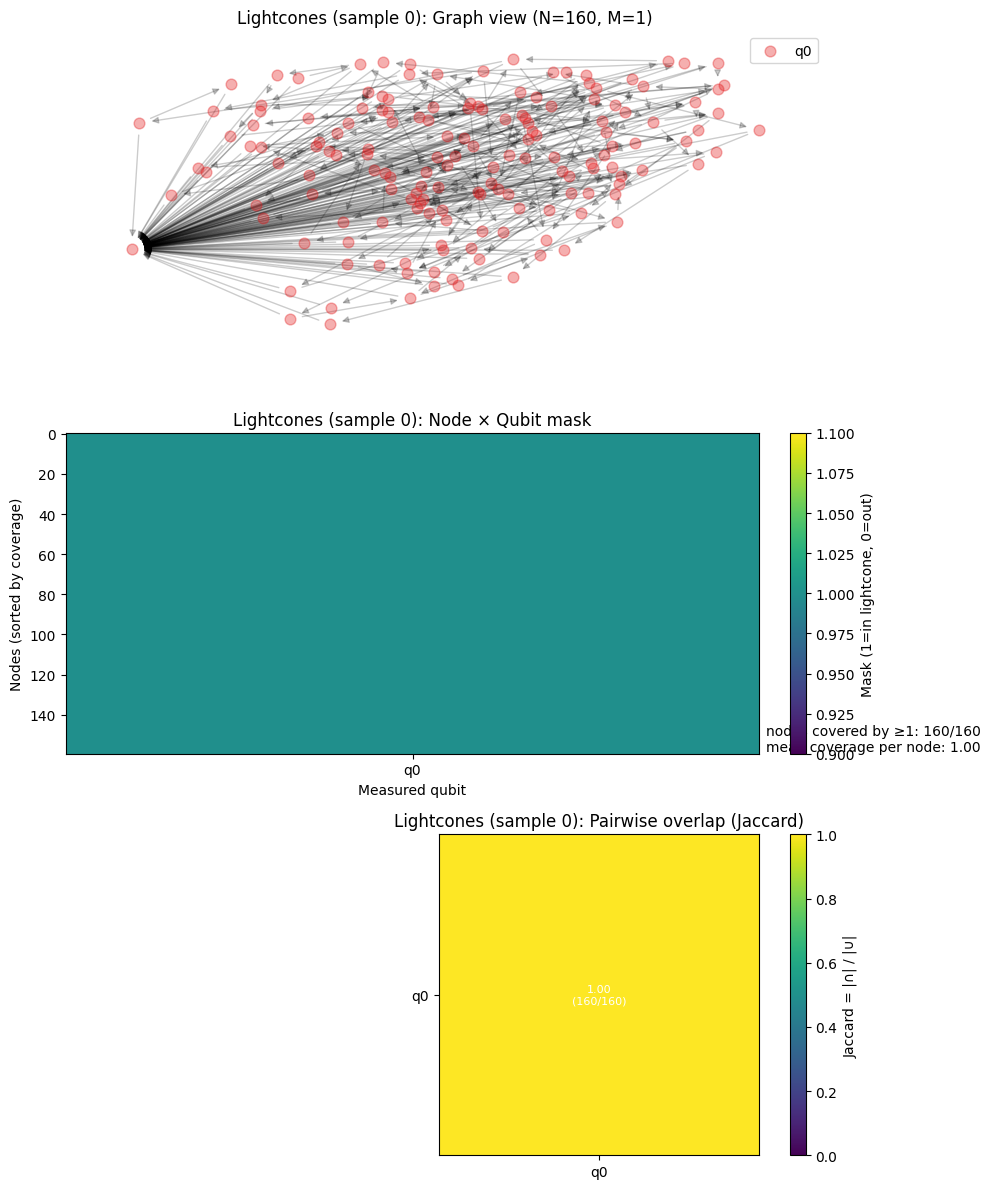

In [5]:
# Grab a batch from your loader (train or val), take the first graph
b = next(iter(train_loader))  # or val_loader
g0 = get_graph_from_batch(b, 0)

# Visualize
visualize_lightcones(
    g0,
    title_prefix="Lightcones (sample 0)",
    show_graph=True,    # requires networkx; if not installed, set False or install networkx
    show_masks=True,
    show_overlap=True
)
